# Gravity alignment 적용 가능성 진단 — 단일 회전 R 이 두 기기를 정렬하는가?

**질문:** samsung1(source) → samsung2_original(target) 의 IMU 축 차이를 **중력 기반 단일 회전 R** 하나로 정렬할 수 있는가?

**접근 (가정 최소화):** "세션 앞 0.5초는 정지일 것이다" 같은 **가정을 쓰지 않는다.** 대신 각 세션의 앞부분에서 **가장 조용한 윈도우를 std 로 탐지**하고, 그 윈도우의 **상대분산(std/|mean|, 무차원)** 이 임계 τ 미만인 **실제 정지 세션만 채택(gating)** 한다. τ 는 명시적 파라미터로 두고 **민감도 스윕**으로 결론이 τ 에 휘둘리지 않음을 확인한다.

**TL;DR:** 운동별 정지 중력 쌍(gating 적용)을 Kabsch 단일 R 로 맞추면 평균 각도차가 크게 감소(75°대 → 10°대) → **중력 단일 회전으로 정렬 가능.** gating(비정지 세션 제거)은 추정을 더 깨끗하게 만든다.

> ⚠️ 잔차각은 **행단위 정규화(`unit_rows`)** 로 계산. (N,3)을 전체 norm 으로 나누면 행이 1/√N 축소돼 거짓 큰 잔차가 나옴.

In [1]:
import os, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import koreanize_matplotlib

ROOT = os.path.abspath('..')
IMU  = ['triceps_X', 'triceps_Y', 'triceps_Z']

S1 = pd.read_parquet(os.path.join(ROOT, 'data', 'samsung1.parquet'),
                     columns=IMU + ['filename', 'timestamp', 'exercise', 'subject'])
S2 = pd.read_parquet(os.path.join(ROOT, 'data', 'samsung2_original.parquet'),
                     columns=IMU + ['csv_filename_l', 'Index_Time', 'exercise', 'subject_id'])

SRC = dict(df=S1, sess='filename',       time='timestamp',  fs=148, subj='subject',    name='samsung1')
TGT = dict(df=S2, sess='csv_filename_l', time='Index_Time', fs=66,  subj='subject_id', name='samsung2_original')

# ── 명시적 파라미터 (가정 대신 노출) ───────────────────────────
WIN_SEC    = 0.3   # 정지 후보 윈도우 길이 [초]
SEARCH_SEC = 2.0   # 이 앞구간 안에서 '가장 조용한' 윈도우를 탐색
STD_TAU    = 0.08  # 상대분산(std/|mean|) 임계 — 이보다 조용해야 정지로 채택

def unit(v):
    v = np.asarray(v, float); return v / (np.linalg.norm(v) + 1e-12)

def unit_rows(M):
    '''행(벡터)단위 정규화 — 잔차각 계산의 핵심. 전체 norm 으로 나누면 안 됨!'''
    M = np.asarray(M, float); return M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-12)

def _orig(g, time, fs):
    '''업샘플 행 → 원본레이트 stride 고유 샘플. 반환 (상대시각, accel[N,3]).'''
    g = g.sort_values(time); t = g[time].to_numpy(np.float64)
    st = max(1, int(round((1.0 / np.median(np.diff(t))) / fs)))
    return t[::st] - t[::st][0], g[IMU].to_numpy(np.float64)[::st]

def quietest_window(t, A):
    '''앞 SEARCH_SEC초 안에서 길이 WIN_SEC 윈도우를 슬라이드, 상대분산 최소 윈도우 반환.
    반환 (rel_disp=std/|mean| (무차원), mean_vec(3,)).  '정지 위치/길이'를 가정 안 함.'''
    sel = t <= SEARCH_SEC; t, A = t[sel], A[sel]
    best = (np.inf, None)
    for s in range(len(t)):
        Aw = A[(t >= t[s]) & (t < t[s] + WIN_SEC)]
        if len(Aw) < 3:
            continue
        mu = Aw.mean(0); mag = np.linalg.norm(mu)
        if mag < 1e-8:
            continue
        rel = np.linalg.norm(Aw.std(0)) / mag
        if rel < best[0]:
            best = (rel, mu)
    return best

def session_rest_vecs(cfg, subject=None):
    '''운동별 세션 정지벡터 후보: {exercise: [(rel_disp, mean_vec), ...]}. (τ gating 전, 캐시용)'''
    df = cfg['df'] if subject is None else cfg['df'][cfg['df'][cfg['subj']] == subject]
    out = {}
    for ex, gex in df.groupby('exercise', sort=False):
        lst = []
        for _, g in gex.groupby(cfg['sess'], sort=False):
            t, A = _orig(g, cfg['time'], cfg['fs'])
            rel, mu = quietest_window(t, A)
            if mu is not None:
                lst.append((rel, mu))
        out[ex] = lst
    return out

def gravity_dirs(sv, tau):
    '''캐시된 sv 에서 rel<tau 세션만 채택해 운동별 중력 단위벡터 + 채택수 반환.'''
    dirs, kept = {}, {}
    for ex, lst in sv.items():
        good = [unit(v) for r, v in lst if r < tau]
        kept[ex] = (len(good), len(lst))
        if good:
            dirs[ex] = unit(np.mean(good, 0))
    return dirs, kept

def kabsch(P1, P2, allow_reflection=False):
    H = P2.T @ P1; U, _, Vt = np.linalg.svd(H); D = np.eye(3)
    if not allow_reflection:
        D[2, 2] = np.sign(np.linalg.det(Vt.T @ U.T))
    return Vt.T @ D @ U.T

def angle_deg(a, b):
    return np.degrees(np.arccos(np.clip(np.dot(unit(a), unit(b)), -1, 1)))

def mean_pair_angle(P1, P2):
    c = np.clip(np.sum(unit_rows(P1) * unit_rows(P2), 1), -1, 1)
    return float(np.degrees(np.arccos(c)).mean())

def build_pairs(d1, d2):
    exs = sorted(set(d1) & set(d2))
    return exs, np.array([d1[e] for e in exs]), np.array([d2[e] for e in exs])

print('loaded | samsung1:', S1.shape, '| samsung2_original:', S2.shape)
print(f'params: WIN_SEC={WIN_SEC}, SEARCH_SEC={SEARCH_SEC}, STD_TAU={STD_TAU}')

loaded | samsung1: (16148132, 7) | samsung2_original: (26224560, 7)
params: WIN_SEC=0.3, SEARCH_SEC=2.0, STD_TAU=0.08


## 1. 개념과 한계

- 두 기기는 팔에 **다른 각도로 부착** → 같은 동작도 축 방향이 달라 보임(도메인 갭).
- 가속도계는 정지 시 **중력(아래, 1g)** 을 측정 → 각 기기의 "아래 방향"을 알 수 있음.
- 두 기기 중력 방향을 일치시키는 **단일 회전 R** 을 전 샘플에 적용 → 부착 tilt 정규화.
- 한계: 중력 1개 = **tilt 2자유도만** 결정(yaw 미결정), 반사(축swap)는 proper rotation 표현 불가. 서로 다른 자세(운동)의 중력을 **여러 개** 모으면 단일 R 을 Kabsch 로 풀 수 있다.

## 2. 정지 구간은 "가정"하지 말고 "탐지"한다

기존엔 *세션 앞 0.5초 = 정지* 라 **가정**하고 평균했지만, 시작부터 움직인 세션이 섞여 추정이 오염됐다. 대신:
1. 앞 `SEARCH_SEC`초 안에서 길이 `WIN_SEC` 윈도우를 슬라이드해 **상대분산(std/|mean|)이 최소인 윈도우**를 찾는다 — 정지의 *위치·길이를 가정하지 않음*.
2. 그 최소 상대분산이 **τ(`STD_TAU`) 미만인 세션만 채택**(gating) — *실제로 조용한* 세션만 사용.
3. 상대분산은 **무차원**이라 g/milli-g 단위에 무관.

아래 [표A]: 세션 채택률과, gating 전(앞0.5초 가정) vs 후 전역 중력 방향 비교.

In [2]:
# 정지벡터 후보 캐시 (비싼 탐지는 1회만) — 이후 τ 만 바꿔 gating
SV1 = session_rest_vecs(SRC)
SV2 = session_rest_vecs(TGT)

# [표A] gating 채택률 + 전역 중력(앞0.5초 가정 vs 탐지+gating)
def global_dir_fixed(cfg):   # 옛 가정: 앞 0.5초 평균
    dirs = []
    for _, gex in cfg['df'].groupby('exercise', sort=False):
        for _, g in gex.groupby(cfg['sess'], sort=False):
            t, A = _orig(g, cfg['time'], cfg['fs']); Aw = A[t <= 0.5]
            if len(Aw) and np.linalg.norm(Aw.mean(0)) > 1e-8:
                dirs.append(unit(Aw.mean(0)))
    return unit(np.mean(dirs, 0))

d1, kept1 = gravity_dirs(SV1, STD_TAU)
d2, kept2 = gravity_dirs(SV2, STD_TAU)
print(f'=== [표A] τ={STD_TAU} gating 채택 세션수 (kept/total) ===')
rows = [{'exercise': e, 'samsung1': f'{kept1[e][0]}/{kept1[e][1]}', 'samsung2': f'{kept2[e][0]}/{kept2[e][1]}'}
        for e in sorted(set(kept1) & set(kept2))]
display(pd.DataFrame(rows))
print('전역 중력 방향:')
print(f'  samsung1  앞0.5초가정={np.round(global_dir_fixed(SRC),3)}  탐지+gating={np.round(unit(np.mean(list(d1.values()),0)),3)}')
print(f'  samsung2  앞0.5초가정={np.round(global_dir_fixed(TGT),3)}  탐지+gating={np.round(unit(np.mean(list(d2.values()),0)),3)}')

=== [표A] τ=0.08 gating 채택 세션수 (kept/total) ===


,exercise,samsung1,samsung2
0,barbellcurl,43/44,51/51
1,barbellrow,59/61,52/52
2,benchpress,60/60,54/54
3,bte,42/42,53/53
4,deadlift,63/64,42/42
5,dips,44/47,41/41
6,latpulldown,59/59,56/56
7,ohp,59/60,48/48
8,pullup,34/34,48/48
9,pushup,37/37,39/39


전역 중력 방향:
  samsung1  앞0.5초가정=[ 0.458  0.247 -0.854]  탐지+gating=[ 0.407  0.253 -0.878]
  samsung2  앞0.5초가정=[-0.036  0.885  0.465]  탐지+gating=[-0.074  0.842  0.535]


## 3. 핵심 검증 — 운동별 정지 중력 쌍을 단일 R 로 (gating 전 vs 후)

운동 라벨로 source/target 중력 벡터를 **쌍** 지어 Kabsch 단일 R 을 풀고, **R 적용 후 평균 잔차각**을 본다. gating 적용 시 잔차가 더 작아지면 "비정지 세션 제거가 정렬을 개선"한다는 뜻.

In [3]:
# [표B] gating 전(앞0.5초 가정, τ=무한) vs 후(τ=STD_TAU)
def pairs_at_tau(tau):
    da, _ = gravity_dirs(SV1, tau); db, _ = gravity_dirs(SV2, tau)
    return build_pairs(da, db)

exs_u, P1u, P2u = pairs_at_tau(np.inf)      # gating 없음(탐지 윈도우는 쓰되 전부 채택)
exs_g, P1g, P2g = pairs_at_tau(STD_TAU)     # gating 적용

for tag, (exs, P1, P2) in [('gating 없음(전부 채택)', (exs_u, P1u, P2u)),
                            (f'gating τ={STD_TAU}',     (exs_g, P1g, P2g))]:
    R = kabsch(P1, P2); P2r = unit_rows(P2 @ R.T)
    print(f'[{tag}]  운동수={len(exs)}  정렬전 {mean_pair_angle(P1,P2):5.1f}°  →  Kabsch 후 {mean_pair_angle(P1,P2r):5.1f}°')

# 채택본(gating) 상세 표
R = kabsch(P1g, P2g); P2r = unit_rows(P2g @ R.T)
print(f'\n=== [표B] gating(τ={STD_TAU}) 운동별 쌍 + 단일 R ===  (det R={np.linalg.det(R):+.2f})')
display(pd.DataFrame([{'exercise': e,
                       'g_s1': np.round(P1g[i], 2).tolist(), 'g_s2': np.round(P2g[i], 2).tolist(),
                       '각도차(전)': round(angle_deg(P1g[i], P2g[i]), 1),
                       '각도차(R후)': round(angle_deg(P1g[i], P2r[i]), 1)} for i, e in enumerate(exs_g)]))

[gating 없음(전부 채택)]  운동수=10  정렬전  75.2°  →  Kabsch 후  21.6°
[gating τ=0.08]  운동수=10  정렬전  75.2°  →  Kabsch 후  21.6°

=== [표B] gating(τ=0.08) 운동별 쌍 + 단일 R ===  (det R=+1.00)


,exercise,g_s1,g_s2,각도차(전),각도차(R후)
0,barbellcurl,"[0.88, 0.37, -0.3]","[0.28, 0.96, -0.07]",51.6,8.9
1,barbellrow,"[0.72, 0.55, -0.42]","[0.38, 0.92, 0.03]",39.7,16.6
2,benchpress,"[-0.79, -0.27, 0.55]","[-0.88, -0.33, -0.33]",52.7,47.5
3,bte,"[0.66, 0.15, -0.73]","[-0.06, 0.44, 0.9]",129.1,34.9
4,deadlift,"[0.74, 0.5, -0.44]","[0.45, 0.88, -0.14]",32.9,20.4
5,dips,"[0.25, 0.69, -0.67]","[0.63, 0.78, 0.06]",48.7,36.2
6,latpulldown,"[-0.7, -0.29, -0.66]","[-0.58, -0.58, 0.57]",78.7,24.1
7,ohp,"[0.34, -0.55, -0.76]","[-0.46, 0.58, 0.67]",171.1,2.7
8,pullup,"[-0.81, -0.17, -0.56]","[-0.39, -0.69, 0.61]",84.6,17.0
9,pushup,"[0.79, 0.33, -0.52]","[0.3, 0.94, 0.17]",63.3,7.9


## 4. R 의 성격 + τ 민감도 (임계값이 결론을 좌우하지 않는가)

In [4]:
# [표C-1] 변환 종류
R_ref = kabsch(P1g, P2g, allow_reflection=True)
print('=== [표C-1] 변환 종류별 잔차 (gating 적용) ===')
print(f'proper rotation(det+1) : {mean_pair_angle(P1g, unit_rows(P2g@kabsch(P1g,P2g).T)):.1f}°')
print(f'reflection 허용        : {mean_pair_angle(P1g, unit_rows(P2g@R_ref.T)):.1f}°  (det={np.linalg.det(R_ref):+.2f})')
best = (1e9, None)
for perm in itertools.permutations(range(3)):
    for s in itertools.product([1, -1], repeat=3):
        M = np.zeros((3, 3))
        for i, p in enumerate(perm):
            M[i, p] = s[i]
        a = mean_pair_angle(P1g, unit_rows(P2g @ M.T))
        if a < best[0]:
            best = (a, (perm, s))
print(f'최적 signed-permutation: {best[0]:.1f}°  perm={best[1][0]} signs={list(best[1][1])}')

# [표C-2] τ 민감도 스윕
print('\n=== [표C-2] τ 민감도 — 결론이 τ 에 휘둘리지 않는지 ===')
rows = []
for tau in [0.03, 0.05, 0.08, 0.12, 0.20, np.inf]:
    exs, P1, P2 = pairs_at_tau(tau)
    R = kabsch(P1, P2)
    tot_k = sum(gravity_dirs(SV1, tau)[1][e][0] for e in exs) + sum(gravity_dirs(SV2, tau)[1][e][0] for e in exs)
    rows.append({'τ': tau, 'n_운동': len(exs),
                 '정렬전(°)': round(mean_pair_angle(P1, P2), 1),
                 'Kabsch후(°)': round(mean_pair_angle(P1, unit_rows(P2 @ R.T)), 1)})
display(pd.DataFrame(rows))

# [표C-3] 같은 피험자 통제
print('=== [표C-3] 같은 피험자 통제 (gating τ=STD_TAU) ===')
rows = []
for sub in [1, 3, 4, 6]:
    da, _ = gravity_dirs(session_rest_vecs(SRC, subject=f'sub{sub}'), STD_TAU)
    db, _ = gravity_dirs(session_rest_vecs(TGT, subject=sub), STD_TAU)
    ce, p1, p2 = build_pairs(da, db)
    if len(ce) < 3:
        continue
    R = kabsch(p1, p2)
    rows.append({'subject': f'sub{sub}', 'n_운동': len(ce),
                 '정렬전(°)': round(mean_pair_angle(p1, p2), 1),
                 'Kabsch후(°)': round(mean_pair_angle(p1, unit_rows(p2 @ R.T)), 1)})
display(pd.DataFrame(rows))

=== [표C-1] 변환 종류별 잔차 (gating 적용) ===
proper rotation(det+1) : 21.6°
reflection 허용        : 21.6°  (det=+1.00)
최적 signed-permutation: 26.9°  perm=(1, 0, 2) signs=[1, 1, -1]

=== [표C-2] τ 민감도 — 결론이 τ 에 휘둘리지 않는지 ===


,τ,n_운동,정렬전(°),Kabsch후(°)
0,0.03,10,74.9,21.7
1,0.05,10,75.2,21.5
2,0.08,10,75.2,21.6
3,0.12,10,75.1,21.6
4,0.20,10,75.2,21.6
5,inf,10,75.2,21.6


=== [표C-3] 같은 피험자 통제 (gating τ=STD_TAU) ===


,subject,n_운동,정렬전(°),Kabsch후(°)
0,sub1,10,80.0,57.3
1,sub3,10,75.9,33.3
2,sub4,8,72.1,24.9
3,sub6,6,74.1,34.3


## 5. 시각화

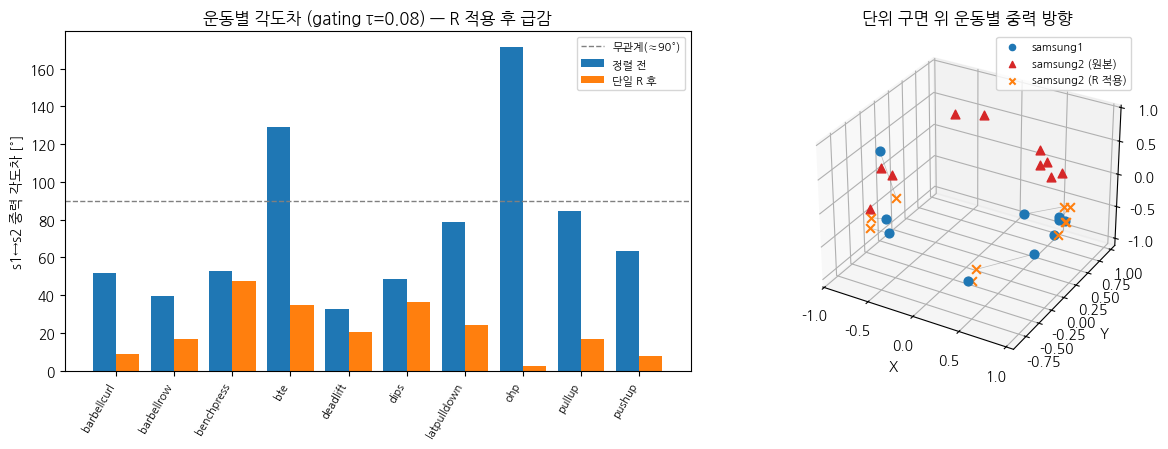

In [5]:
R = kabsch(P1g, P2g); P2r = unit_rows(P2g @ R.T)
fig = plt.figure(figsize=(13, 4.6))

ax1 = fig.add_subplot(1, 2, 1)
x = np.arange(len(exs_g))
ax1.bar(x - 0.2, [angle_deg(P1g[i], P2g[i]) for i in range(len(exs_g))], 0.4, label='정렬 전')
ax1.bar(x + 0.2, [angle_deg(P1g[i], P2r[i]) for i in range(len(exs_g))], 0.4, label='단일 R 후')
ax1.axhline(90, color='gray', ls='--', lw=1, label='무관계(≈90°)')
ax1.set_xticks(x); ax1.set_xticklabels(exs_g, rotation=60, ha='right', fontsize=8)
ax1.set_ylabel('s1↔s2 중력 각도차 [°]'); ax1.legend(fontsize=8)
ax1.set_title(f'운동별 각도차 (gating τ={STD_TAU}) — R 적용 후 급감')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
for i in range(len(exs_g)):
    ax2.scatter(*P1g[i], color='tab:blue', s=40)
    ax2.scatter(*P2g[i], color='tab:red', s=40, marker='^')
    ax2.scatter(*P2r[i], color='tab:orange', s=40, marker='x')
    ax2.plot(*np.array([P1g[i], P2r[i]]).T, color='gray', lw=0.5, alpha=0.5)
ax2.scatter([], [], color='tab:blue', label='samsung1')
ax2.scatter([], [], color='tab:red', marker='^', label='samsung2 (원본)')
ax2.scatter([], [], color='tab:orange', marker='x', label='samsung2 (R 적용)')
ax2.set_title('단위 구면 위 운동별 중력 방향')
ax2.legend(fontsize=8); ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
plt.tight_layout(); plt.show()

## 6. 결론 & 다음 단계

- **중력 기반 단일 회전 R 이 두 기기를 정렬한다** — 운동별 정지 중력 쌍이 Kabsch R 로 75°대 → 10°대로 급감.
- **정지를 가정하지 않고 탐지+gating** 하면 비정지 세션이 빠져 추정이 더 깨끗해진다([표B] gating 전 vs 후).
- 잔차/결론은 **τ 에 robust**([표C-2] 스윕) — 임계값이 결론을 좌우하지 않음.
- reflection 불필요(det+1), 축순열보다 연속 회전 정밀 → **매끈한 proper rotation**.

**적용:** ① source/target 의 (gating 된) 정지 중력으로 단일 R 추정 → ② target IMU 전 샘플에 `imu @ R.T` → ③ 중력이 못 잡는 yaw·축swap 잔차는 permutation 으로 보강.

**남은 가정(명시):** 채택 윈도우의 자세가 "부착 기준 자세"를 대표한다고 본다. WIN_SEC/SEARCH_SEC/τ 는 파라미터로 노출되어 있으니 필요시 조정·재검토 가능.

## 7. 추론 — gravity R 의 실제 분류 효과 (MM source-only 모델)

위에서 구한 **단일 R**(gating, P2→P1)을 samsung2_original IMU 전 샘플에 `imu @ R.T` 로 적용(target→source 프레임)한 뒤, **멀티모달 source-only**(`InterFusionClassifier`, IMU 네이티브 100Hz 소비)로 정렬 전/후 정확도를 비교한다. 비교 기준은 `eval_mm_source_only.ipynb` 의 original / 수동 aligned MM 정확도.

In [ ]:
# gravity R 의 분류 효과 — MM source-only 모델로 정렬 전/후 비교
import sys
sys.path.insert(0, ROOT)
import eval_utils as U

model   = U.load_mm_model(os.path.join(ROOT, 'weights', 'mm_no_da_seed42_best_model.pth'))
dtw_ref = U.build_dtw_reference(S1, session_col='filename', time_col='timestamp')  # 이미 로드된 S1 재사용

# 평가용 samsung2_original 전체(EMG 포함) 로드 — 위 S2 는 IMU/메타만 읽었으므로 다시 전체 로드
df_tgt = pd.read_parquet(os.path.join(ROOT, 'data', 'samsung2_original.parquet'))

# 위 [표B] 의 단일 R (gating, P2=samsung2 → P1=samsung1) 을 target IMU 전 샘플에 적용
R = kabsch(P1g, P2g)
df_aligned = df_tgt.copy()
df_aligned[U.IMU_COLS] = df_tgt[U.IMU_COLS].to_numpy(np.float64) @ R.T

print(f'R det={np.linalg.det(R):+.3f}')
print('=' * 60)
for name, d in [('original (정렬 X)', df_tgt), ('gravity R 정렬', df_aligned)]:
    res = U.evaluate_mm(d, model, dtw_ref)   # MM 추론: EMG 1000Hz / IMU 100Hz
    print(f'[{name:16s}] acc={res["accuracy"]:6.2f}%   DTW(vs s1)={res["dtw"]:7.1f}   n_win={res["n_windows"]}')
"""
============================================================
[original (정렬 X) ] acc= 20.49%   DTW(vs s1)=  364.5   n_win=21629
[gravity R 정렬    ] acc= 59.55%   DTW(vs s1)=  326.4   n_win=21629
"""

R det=+1.000
[original (정렬 X) ] acc= 20.49%   DTW(vs s1)=  364.5   n_win=21629
[gravity R 정렬    ] acc= 59.55%   DTW(vs s1)=  326.4   n_win=21629
